# Data Understanding: Raman Spectral Arrays

This notebook documents the first-pass exploration of the raw dataset stored directly inside `data/raw/`.

Goals:
- inspect what files are present in the raw data folder
- verify array shapes and split alignment
- understand the label structure across splits
- inspect the shared Raman axis (`wavenumbers.npy`)
- look at intensity statistics and representative spectra
- summarize the main modeling implications

In [4]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'experiments').exists():
            return candidate
    raise RuntimeError('Could not locate the project root from the current notebook session.')

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from experiments.inspect_dataset_utils import (
    archive_file_summary,
    array_metadata_frame,
    label_distribution_frame,
    label_set_summary,
    load_array,
    plot_representative_spectra,
    sampled_intensity_statistics,
    split_sample_summary,
    wavenumber_summary,
)

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)
pd.set_option('display.max_rows', 200)

DATA_ROOT = PROJECT_ROOT / 'data' / 'raw'
DATA_ROOT

WindowsPath('S:/Raman_classification_project/data/raw')

## 1. Raw Data Folder Contents

The arrays are stored directly inside `data/raw/`, so we begin by listing the available files and their sizes.

In [5]:
file_summary = archive_file_summary(DATA_ROOT)
display(file_summary)

print(f"Total files in raw folder: {len(file_summary)}")
print(f"Total size (MB): {file_summary['size_bytes'].sum() / 1024**2:.2f}")

,file_name,compressed_size_bytes,size_bytes
0,X_2018clinical.npy,80000128,80000128
1,X_2019clinical.npy,20000128,20000128
2,X_finetune.npy,24000128,24000128
3,X_reference.npy,480000128,480000128
4,X_test.npy,24000128,24000128
5,wavenumbers.npy,8080,8080
6,y_2018clinical.npy,80128,80128
7,y_2019clinical.npy,20128,20128
8,y_finetune.npy,24128,24128
9,y_reference.npy,480128,480128


Total files in raw folder: 11
Total size (MB): 599.52


## 2. Array Metadata

Each `.npy` file is inspected through its header so we can confirm shapes, dtypes, and storage layout.

In [6]:
metadata = array_metadata_frame(DATA_ROOT)
display(metadata)

,array_name,shape,dtype,fortran_order,npy_version
0,X_2018clinical.npy,"(10000, 1000)",<f8,False,1.0
1,X_2019clinical.npy,"(2500, 1000)",<f8,False,1.0
2,X_finetune.npy,"(3000, 1000)",<f8,False,1.0
3,X_reference.npy,"(60000, 1000)",<f8,False,1.0
4,X_test.npy,"(3000, 1000)",<f8,False,1.0
5,wavenumbers.npy,"(1000,)",<f8,False,1.0
6,y_2018clinical.npy,"(10000,)",<f8,False,1.0
7,y_2019clinical.npy,"(2500,)",<f8,False,1.0
8,y_finetune.npy,"(3000,)",<f8,False,1.0
9,y_reference.npy,"(60000,)",<f8,False,1.0


In [7]:
split_summary = split_sample_summary(DATA_ROOT)
display(split_summary)

print(f"Total spectra across all feature arrays: {split_summary['num_samples'].sum():,}")

,split,num_samples,num_features
0,2018clinical,10000,1000
1,2019clinical,2500,1000
2,finetune,3000,1000
3,reference,60000,1000
4,test,3000,1000


Total spectra across all feature arrays: 78,500


### Observations

- The raw folder contains feature arrays (`X_*`), label arrays (`y_*`), and one shared Raman axis (`wavenumbers.npy`).
- All feature arrays have 1000 columns, so every spectrum currently has 1000 sampled positions.
- The dataset contains 78,500 spectra in total.

## 3. Label Structure Across Splits

A key question is whether all splits cover the same label space. This matters a lot for how we define training, validation, test, and external-domain evaluation.

In [8]:
label_sets = label_set_summary(DATA_ROOT)
display(label_sets)

,split,num_classes,labels,min_label,max_label
0,2018clinical,5,"[0, 2, 3, 5, 6]",0,6
1,2019clinical,5,"[0, 2, 3, 5, 6]",0,6
2,finetune,30,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]",0,29
3,reference,30,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]",0,29
4,test,30,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]",0,29


In [9]:
label_counts = label_distribution_frame(DATA_ROOT)
label_pivot = label_counts.pivot(index='label', columns='split', values='count').fillna(0).astype(int)
display(label_pivot)

split,2018clinical,2019clinical,finetune,reference,test
label,,,,,
0,2000,500,100,2000,100
1,0,0,100,2000,100
2,2000,500,100,2000,100
3,2000,500,100,2000,100
4,0,0,100,2000,100
5,2000,500,100,2000,100
6,2000,500,100,2000,100
7,0,0,100,2000,100
8,0,0,100,2000,100


In [10]:
full_task_labels = set(range(30))
clinical_labels = set(label_counts.loc[label_counts['split'] == '2018clinical', 'label'].tolist())

print('Main non-clinical task labels:', sorted(full_task_labels))
print('Clinical subset labels:', sorted(clinical_labels))
print('Clinical labels are subset of the 30-class task:', clinical_labels.issubset(full_task_labels))

Main non-clinical task labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Clinical subset labels: [0, 2, 3, 5, 6]
Clinical labels are subset of the 30-class task: True


### Label Insights

- `reference`, `finetune`, and `test` each cover all 30 classes.
- The class balance is perfectly uniform within those three splits.
- `2018clinical` and `2019clinical` contain only 5 classes: `{0, 2, 3, 5, 6}`.
- This suggests the dataset supports two related evaluation settings:
  1. a full 30-class benchmark (`reference` / `finetune` / `test`)
  2. a clinical subset benchmark or external-domain setting (`2018clinical` / `2019clinical`)

## 4. Raman Axis (`wavenumbers.npy`)

The feature arrays do not store an x-axis per sample, so the shared Raman axis is important. We inspect whether it is ascending or descending and how densely it is sampled.

In [11]:
axis_info = wavenumber_summary(DATA_ROOT)
display(pd.Series(axis_info))

count                                             1000
min                                             381.98
max                                             1792.4
first_five    [1792.4, 1791.2, 1789.9, 1788.6, 1787.3]
last_five     [388.21, 386.65, 385.09, 383.54, 381.98]
descending                                        True
mean_step                                    -1.411832
min_step                                         -1.56
max_step                                          -1.2
dtype: object

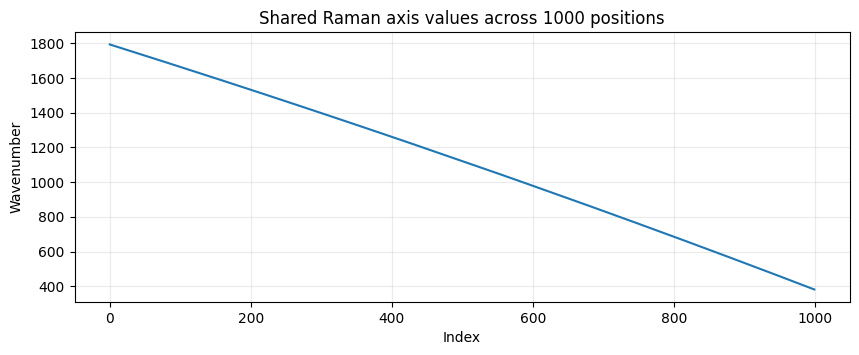

In [12]:
wavenumbers = load_array(DATA_ROOT, 'wavenumbers.npy')
plt.figure(figsize=(10, 3.5))
plt.plot(wavenumbers, linewidth=1.5)
plt.title('Shared Raman axis values across 1000 positions')
plt.xlabel('Index')
plt.ylabel('Wavenumber')
plt.grid(alpha=0.25)
plt.show()

### Axis Insights

- The axis has 1000 points.
- It is stored in descending order, approximately from `1792.4` down to `381.98`.
- The step size is close to uniform but not exactly constant.
- Any modeling or plotting code should treat this as a real Raman axis rather than a generic sample index.

## 5. Sampled Intensity Statistics

We compute summary statistics from a random subset of rows in each split to understand the intensity range and whether the spectra already appear normalized.

In [13]:
sample_stats = sampled_intensity_statistics(DATA_ROOT, sample_size=256, seed=42)
display(sample_stats)

,split,sampled_rows,global_min,global_max,mean_of_row_means,std_of_row_means,mean_of_row_stds,std_of_row_stds
0,2018clinical,256,0.0,1.0,0.462632,0.041249,0.154861,0.010951
1,2019clinical,256,0.0,1.0,0.447775,0.046838,0.155887,0.012236
2,finetune,256,0.0,1.0,0.417667,0.075438,0.153028,0.015939
3,reference,256,0.0,1.0,0.430541,0.078248,0.158420,0.017351
4,test,256,0.0,1.0,0.427701,0.062324,0.155438,0.014261


### Intensity Insights

- Many spectra appear bounded in the `0` to `1` range.
- Some splits consistently touch `1.0`, which suggests at least partial normalization has already happened upstream.
- Even so, split-wise mean and variance are not identical, so preprocessing choices such as SNV or standardization may still matter.

## 6. Representative Spectra

Plotting a few examples from each split helps us check that the arrays really behave like spectra and lets us visually compare standard and clinical domains.

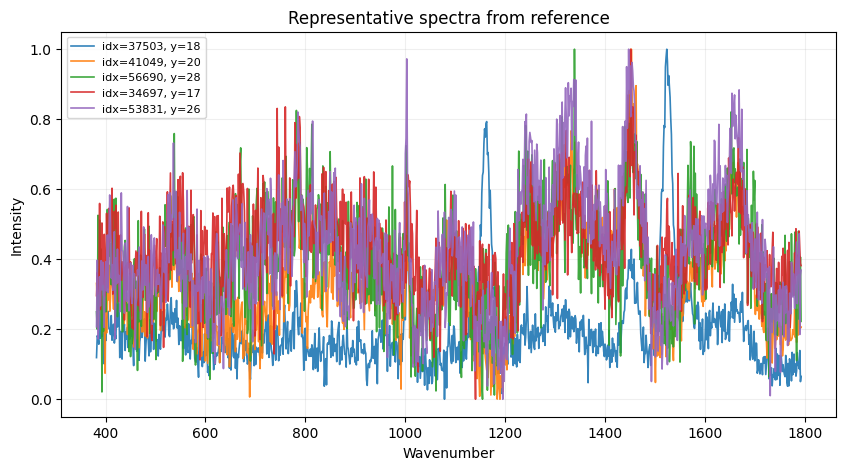

In [14]:
plot_representative_spectra(DATA_ROOT, 'reference', num_examples=5, seed=7)
plt.show()

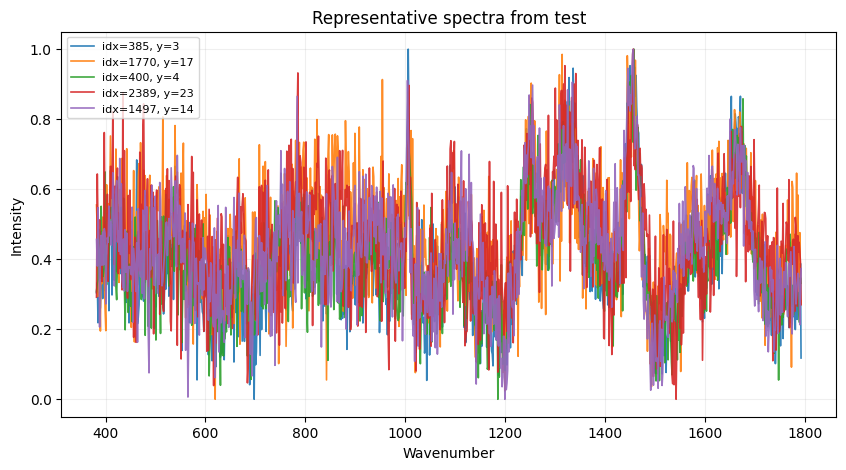

In [15]:
plot_representative_spectra(DATA_ROOT, 'test', num_examples=5, seed=11)
plt.show()

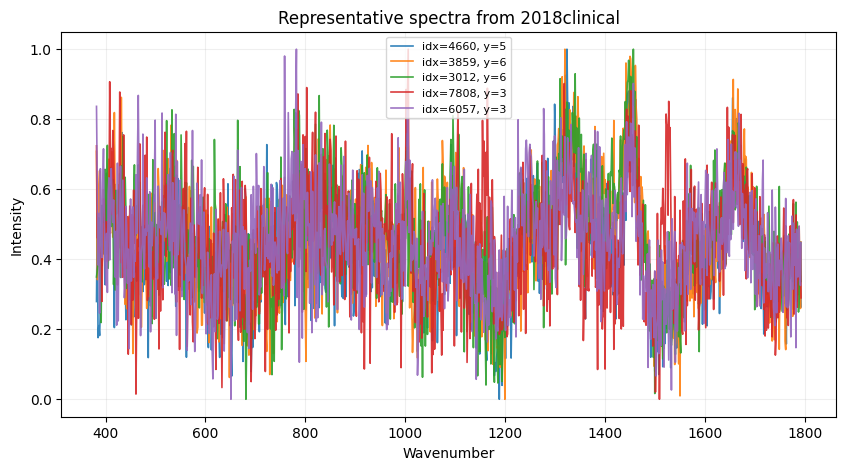

In [16]:
plot_representative_spectra(DATA_ROOT, '2018clinical', num_examples=5, seed=21)
plt.show()

## 7. Main Takeaways

From this first inspection, the dataset appears to support a strong staged research plan:

- Start with a 30-class benchmark using `reference` for training, `finetune` for validation, and `test` for held-out testing.
- Treat `2018clinical` and `2019clinical` as a separate clinical-domain evaluation because they only cover a 5-class subset.
- Preserve the shared Raman axis carefully during plotting and interpretation.
- Keep preprocessing configurable because the data looks partly normalized but not necessarily identical across splits.
- Before writing a final report, find the mapping from numeric labels to real class names so results become scientifically interpretable.